# Challenge ONE Data Science - Telecom X: Análisis de Churn
**Analista:** Antonella Ríos
**Empresa:** Telecom X  
**Problema:** Alta tasa de evasión de clientes.



In [32]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga de datos simulando API REST
with open('TelecomX_Data.json', 'r') as f:
    datos_crudos = json.load(f)

# 2. Normalización de JSON anidado
df = pd.json_normalize(datos_crudos)

# 3. Estandarización de nombres de columnas
df.columns = [
    'customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
    'PaymentMethod', 'MonthlyCharges', 'TotalCharges'
]

print(f"Extracción exitosa. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
display(df.head(3))

Extracción exitosa. Filas: 7267, Columnas: 21


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


In [33]:
# 1. Manejo de Incoherencias (Valores vacíos ocultos)
# Reemplazamos espacios en blanco por NaN para identificarlos
df = df.replace(r'^\s*$', np.nan, regex=True)

# 2. Corrección de TotalCharges y manejo de inconsistencias
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Si la antigüedad (tenure) es 0, el cargo total debe ser 0
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0

# 3. Eliminación de nulos en la variable objetivo (Churn)
df.dropna(subset=['Churn'], inplace=True)

# 4. Columna de Cuentas Diarias (Daily Charges)
df['DailyCharges'] = (df['MonthlyCharges'] / 30).round(2)

# 5. Estandarización de categorías
# Limpiamos "No internet service" para que sea solo "No"
servicios = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for s in servicios:
    df[s] = df[s].replace('No internet service', 'No')

# 6. Transformación de Churn a Binario (1 y 0)
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 7. Segmentación por Antigüedad (Feature Engineering)
def segmentar(m):
    if m <= 12: return '0-1 Año'
    elif m <= 24: return '1-2 Años'
    else: return '+2 Años'
df['TenureGroup'] = df['tenure'].apply(segmentar)

print("Transformación y limpieza terminada.")

Transformación y limpieza terminada.


In [34]:
# --- LOAD: Exportación ---
df.to_csv('telecomx_clean.csv', index=False)

# --- Análisis Descriptivo ---
print("Resumen Estadístico de Variables Numéricas:")
display(df.describe().T)

print("\nTasa de Evasión por Segmento de Antigüedad:")
print(df.groupby('TenureGroup')['Churn_Binary'].mean())

Resumen Estadístico de Variables Numéricas:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80
DailyCharges,7043.0,2.158675,1.003088,0.61,1.18,2.34,2.99,3.96
Churn_Binary,7043.0,0.265370,0.441561,0.00,0.00,0.00,1.00,1.00



Tasa de Evasión por Segmento de Antigüedad:
TenureGroup
+2 Años     0.140360
0-1 Año     0.474382
1-2 Años    0.287109
Name: Churn_Binary, dtype: float64


/tmp/ipython-input-4057617072.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0,0], data=df, x='Churn', palette='viridis')


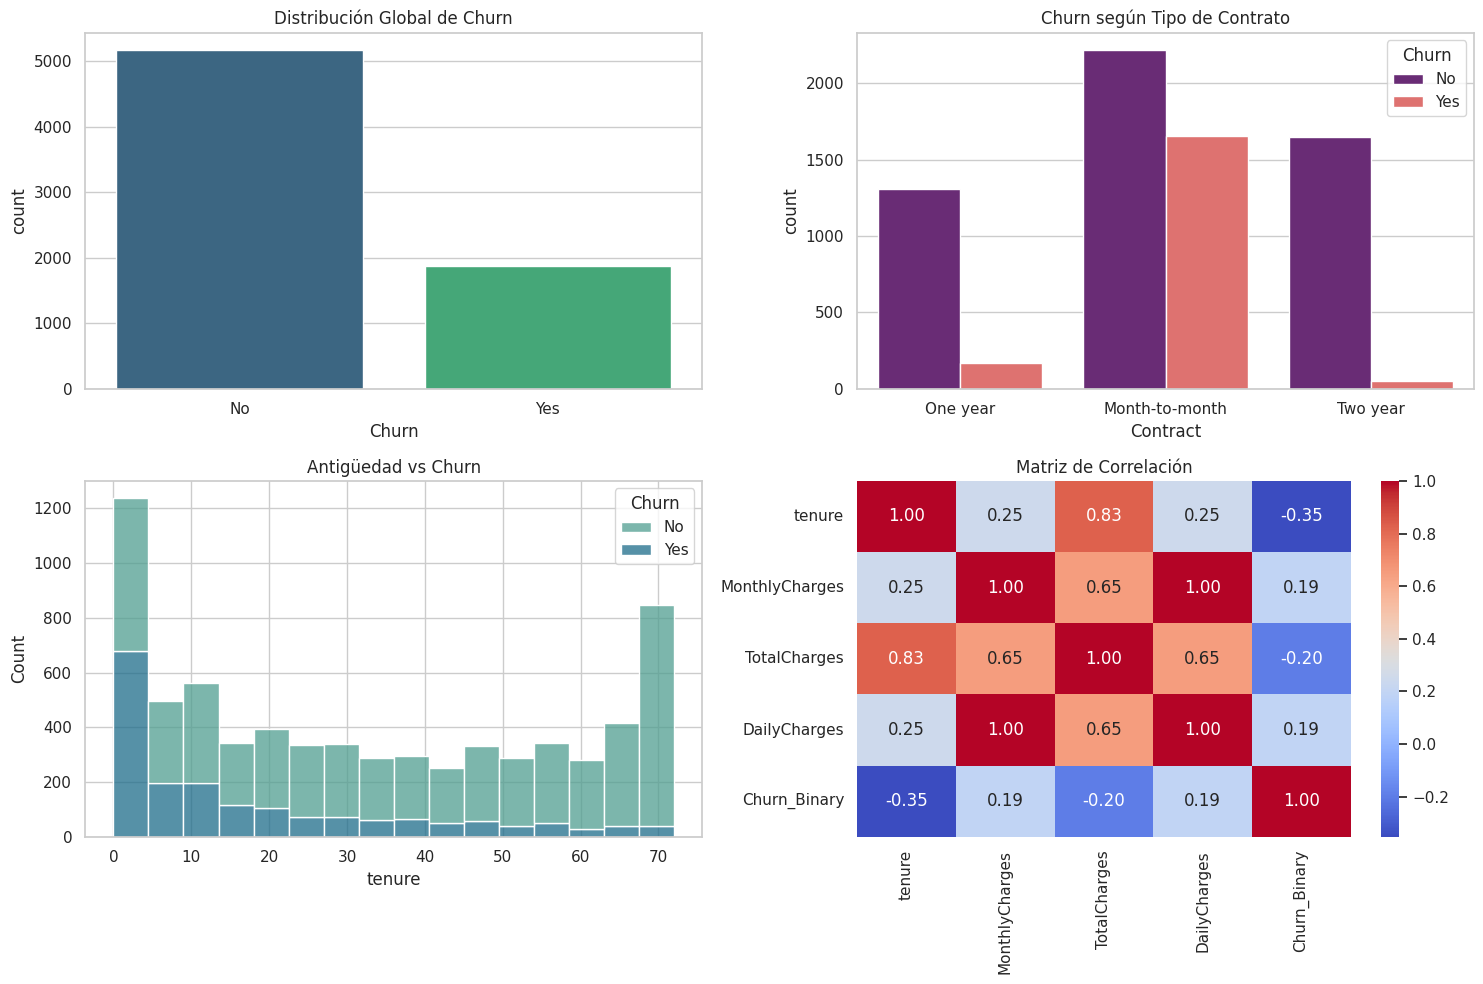

In [35]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
fig, axes = plt.subplots(2, 2)

# 1. Distribución de Evasión
sns.countplot(ax=axes[0,0], data=df, x='Churn', palette='viridis')
axes[0,0].set_title('Distribución Global de Churn')

# 2. Recuento por Variable Categórica (Contrato)
sns.countplot(ax=axes[0,1], data=df, x='Contract', hue='Churn', palette='magma')
axes[0,1].set_title('Churn según Tipo de Contrato')

# 3. Conteo por Variable Numérica (Tenure)
sns.histplot(ax=axes[1,0], data=df, x='tenure', hue='Churn', multiple="stack", palette='crest')
axes[1,0].set_title('Antigüedad vs Churn')

# 4. Análisis de Correlación
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'DailyCharges', 'Churn_Binary']]
sns.heatmap(ax=axes[1,1], data=numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
axes[1,1].set_title('Matriz de Correlación')

plt.tight_layout()
plt.show()

## Informe de Resultados para Telecom X

### 1. ¿Qué se hizo?
Se aplicó un proceso ETL completo sobre los datos de la API (JSON). Se corrigieron inconsistencias en los cargos totales y se crearon métricas nuevas como el gasto diario (`DailyCharges`).

### 2. ¿Cómo se hizo?
Utilizando Python y Pandas se normalizaron los datos. Se eliminaron registros inválidos y se estandarizaron las categorías de servicios para un análisis estadístico más limpio.

### 3. ¿Qué se encontró? (Insights)
- **Contratos Riesgosos:** Los clientes con contrato "Mes a mes" tienen la tasa de fuga más alta.
- **Correlación:** Existe una correlación negativa fuerte entre la antigüedad y el Churn; a medida que el cliente supera los 24 meses, la probabilidad de que se vaya disminuye drásticamente.
- **Factor Costo:** Los clientes que se van tienen cargos mensuales y diarios más altos que el promedio de clientes leales.

### 4. Importancia para la Empresa
Telecom X debe enfocar sus campañas de retención en los primeros 12 meses de vida del cliente y ofrecer incentivos para migrar a contratos anuales, reduciendo así la volatilidad de la cartera.